## Module 4: Cancer

## Team Members:
Kai-Tang Tseng, Mohamed Elfaki

## Project Title:
Evaluating the impact of Cancer Hallmark : Angiogenesis on the progression of Gioblastoma (GBM)



## Project Goal:
This project aims to analyze the role of angiogenesis in glioblastoma (GBM) by examining the expression of angiogenic genes such as VEGFA in tumor datasets.

## Disease Background: 
Low-Grade Giloma (LGG - Grade 1,2) and Gilblastoma Multiforme (GBM - Grade 4)

### Gilblastoma Multiforme (also known as just Giloblastoma)'s Background Information

* Prevalence & incidence : Glioblastoma is the most common primary malignant brain tumor in adults, with an incidence of approximately 3–4 cases per 100,000 people per year. It has a very poor prognosis, with median survival around 12–15 months.

* Risk factors (genetic, lifestyle) & Societal determinants : isk factors include genetic mutations, prior exposure to radiation, and age (more common in older adults). Lifestyle factors are not strongly linked, but access to healthcare can influence diagnosis and outcomes.

* Standard of care treatments (& reimbursement) : Standard treatment includes surgical removal of the tumor followed by radiation therapy and chemotherapy (typically temozolomide). Despite treatment, recurrence is common due to the tumor’s aggressive nature.

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology) : Glioblastoma grows rapidly and invades surrounding brain tissue. It promotes angiogenesis through factors like VEGFA, which stimulate blood vessel formation to supply nutrients and oxygen, supporting tumor survival and expansion. (There are some Giloblastoma, specifically Secondary Giloblastoma which can progress from a Low Grade Giloma (LGG) into Giloblastoma Multiforme. (Primary refers to the Giloblastoma just appears without LGG)) (Ohgaki & Kleihues, 2013)

### Cancer Hallmark : 

* Cancer hallmark focus: Angiogenesis

* Overview of hallmark: Angiogenesis is the process by which new blood vessels form from existing ones. In cancer, this allows tumors to receive oxygen and nutrients, enabling rapid growth and survival. Glioblastoma (GBM) is a highly aggressive brain tumor that relies heavily on angiogenesis to sustain its rapid progression.

* Genes associated with hallmark to be studied : CXCR4	CXCL13	FLT4	RHOA	TGFB2	GAB1	STAT3	LCK	FZD4	PDPK1	CDH5	HIF1A	MTOR	CXCL12	ITGA5	PLCG1	RRAS	ENG	TNFSF12	PTPN11	TGFBR1	TERT	PIK3CD	PTK2B	LEP	FGF2	NOS3	VTN	CCL24	SMO	KDR	PRKCG	RAF1	VEGFA	BRCA1	CCL2	TGFBR2	EGFR	VAV2	VEGFB	KRAS	IL6	ERBB2	PRKCA	ROCK1	TNF	IL1B	SDC4	PRKACA	CX3CR1	ITGB1	PDGFA	CD40	MAPK1	CXCL8	PIK3R1	FIGF	CSF3	HGF	VEGFD	IL10	MET	TP53	SDC2	TGFB1	AKT1	FLT1	CAV1	ARNT	ARHGEF1	PDGFRA	HSPB1	TWIST1	ITGB3	AKT3	MMP1	MAPK3	SPHK1	EPAS1	TIMP3	CXCR2	SRC	CXCL10	MAP2K1	WNT5A	EFNA1	IGF1	IL8	ROCK2	ACKR3	GATA2	VEGFC	CCR3	CTNNB1	TEK	FN1	EPHA2	IGF1R	THBS1	FES	ITGAV	CXCL9	CCL11	MYC	CXCR3	PRKCB	ACVRL1	HRAS	ESR1	TGFB3	PLAUR	RAC1	NF1	ANGPT2	GRB2	PIK3CA	IL1A 


Additional Genes linked to Angiogenesis of Glioblastoma : CXCR1, CXCR2, PDGFB (Biterge-Sut,2020 & D'Alessio et al, 2016)


## Data-Set: 

In this study, we will analysis the subset of Glioblastoma Multiforme (GBM).

Our primarily objective is to analysis the angiogenesis gene difference between a LGG and Glioblastoma to see how the more aggressive Glioblastoma increase the angiogenesis factors, for this we will use subset of RNA Analysis to quantify the Gene Dosage in order to compare how the different cancer type hijake the vascular angiogenesis network differently in intensity.

Supplementary analysis using the metadata allows for comparing race and age to see if those factors can also play a role in the angiogenesis gene expression.

The data is collected from The Cancer Genome Atlas Program (TCGA) which collects the metadata and the RNA Gene Expression Data. For each cancer patients, a specific ID is assigned, and metadata such as background information including cancer stages, age, sex, and other informations are collected. Gene Expression Data is collected through RNA extraction from the patient's sample where the RNA is then sequenced and quantified using Next Generation Sequencing. Gene expression is measured in Transcripts Per Million (TPM), a unit that normalized for gene length. It is then further transformed using the following formula : $\log_{2}(\text{TPM} + 1)$ to reduce data skewness. (1 is added to handle zero-expression values).

The data can be access here : https://portal.gdc.cancer.gov/ 


## Data Analysis: 


In [54]:
import pandas as pd # Pandas
import numpy as np # Numpy
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.decomposition import PCA

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_subsample_log2TPM.csv', index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    '../Data/TRAINING_SET_GSE62944_metadata.csv', index_col=0, header=0)
print(data.head())



        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG                        3.789771                      3.967578   
A1CF                        0.065051                      0.000000   
A2M                         9.024479                      7.573842   
A2ML1                       0.428689                      0.465410   
A4GALT                      4.072650                      4.208381   

        TCGA-LL-A5YN-01A-11R-A28M-07  TCGA-BH-A0DQ-01A-11R-A084-07  \
A1BG                        4.733007                      3.011343   
A1CF              

In [56]:
cancer_type = 'GBM'  # Breast Invasive Carcinoma

# From metadata, get the rows where "cancer_type" is equal to the specified cancer type
# Then grab the index of this subset (these are the sample IDs)
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
print(cancer_samples)
# Subset the main data to include only these samples
# When you want a subset of columns, you can pass a list of column names to the data frame in []
GBM_data = data[cancer_samples]

Index(['TCGA-06-0184-01A-01R-1849-01', 'TCGA-27-2524-01A-01R-1850-01',
       'TCGA-27-1835-01A-01R-1850-01', 'TCGA-26-5139-01A-01R-1850-01',
       'TCGA-06-2567-01A-01R-1849-01', 'TCGA-28-5216-01A-01R-1850-01',
       'TCGA-06-0168-01A-01R-1849-01', 'TCGA-32-1980-01A-01R-1850-01',
       'TCGA-76-4932-01A-01R-1850-01', 'TCGA-06-2557-01A-01R-1849-01',
       'TCGA-06-0141-01A-01R-1849-01', 'TCGA-06-0211-01B-01R-1849-01',
       'TCGA-06-0210-01A-01R-1849-01', 'TCGA-26-5136-01B-01R-1850-01',
       'TCGA-14-1823-01A-01R-1849-01', 'TCGA-15-0742-01A-01R-1850-01',
       'TCGA-41-2572-01A-01R-1850-01', 'TCGA-26-5133-01A-01R-1850-01',
       'TCGA-06-2570-01A-01R-1849-01', 'TCGA-19-1390-01A-01R-1850-01',
       'TCGA-28-5208-01A-01R-1850-01', 'TCGA-12-3650-01A-01R-1849-01',
       'TCGA-16-0846-01A-01R-1850-01', 'TCGA-12-5299-01A-02R-1849-01',
       'TCGA-32-1982-01A-01R-1850-01', 'TCGA-06-0174-01A-01R-1849-01',
       'TCGA-19-2619-01A-01R-1850-01', 'TCGA-06-0125-01A-01R-1849-01',
      

In [57]:
desired_gene_list = ['VEGFA', 'VEGFB', 'KDR', 'CXCR1', 'CXCR2', 'HIF1A', 'PDGFB', 'MYC', 'CDH5', 'KRAS', 'IL8']

gene_list = [gene for gene in desired_gene_list if gene in GBM_data.index]
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")

# .loc[] is the method to subset by index labels
# .iloc[] will subset by index position (integer location) instead
GBM_gene_data = GBM_data.loc[gene_list]
print(GBM_gene_data)

       TCGA-06-0184-01A-01R-1849-01  TCGA-27-2524-01A-01R-1850-01  \
VEGFA                      6.298026                      8.350761   
VEGFB                      7.657397                      7.286662   
KDR                        3.332119                      2.700655   
CXCR1                      1.511057                      0.000000   
CXCR2                      2.449790                      0.559835   
HIF1A                      7.055818                      6.267098   
PDGFB                      5.555408                      4.138285   
MYC                        4.632547                      6.025762   
CDH5                       4.459150                      4.332953   
KRAS                       3.930675                      3.263076   
IL8                        4.311605                      6.931306   

       TCGA-27-1835-01A-01R-1850-01  TCGA-26-5139-01A-01R-1850-01  \
VEGFA                      7.761174                      9.492876   
VEGFB                      7.9877

In [ ]:
# x = Gene data
# Question tumor stage image or overll survival number of weeks. And target can just be > a number

## PCA

C:\Users\kaits\AppData\Local\Temp\ipykernel_14360\1661782031.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Species")


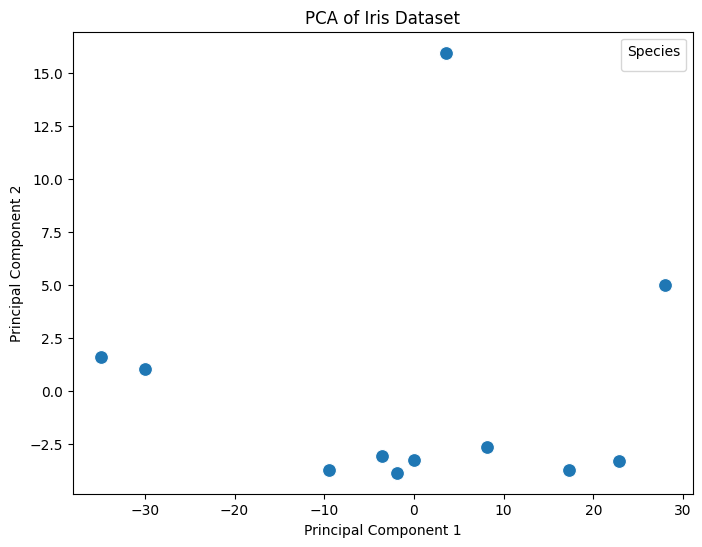

In [80]:
X = GBM_gene_data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0],
                y=X_pca[:, 1],
                #hue=iris.target,
                #palette="Set2",
                s=100)
plt.title("PCA of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Species")
plt.show()

C:\Users\kaits\AppData\Local\Temp\ipykernel_14360\3649001317.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Genes")


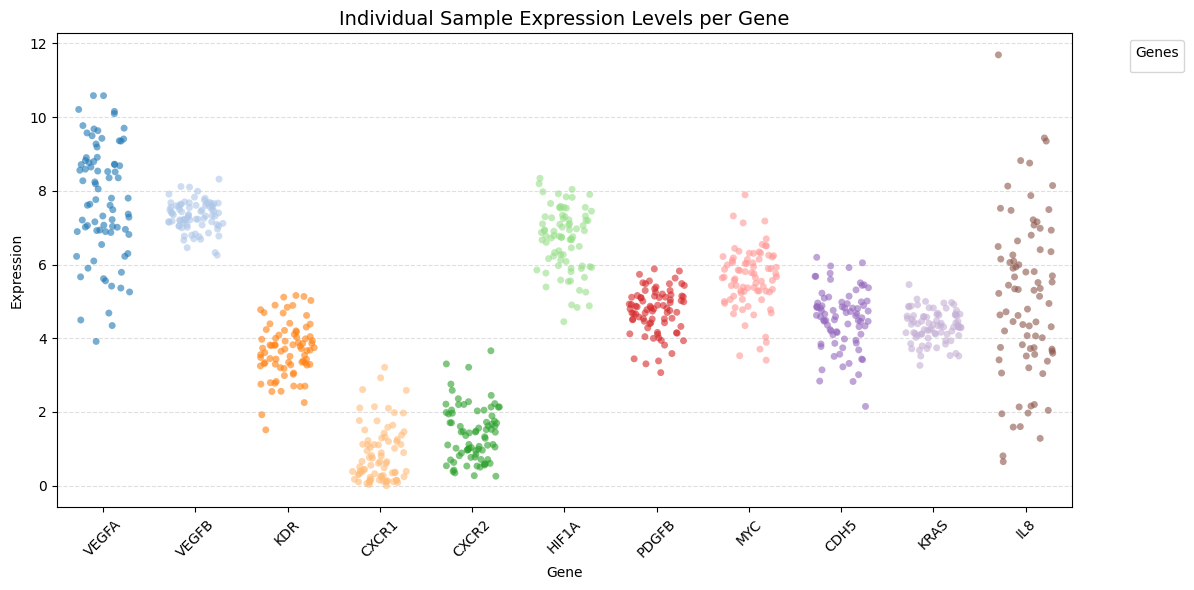

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Transform data from Wide to Long format
# This creates a table with columns: [Gene, Sample_ID, Expression_Value]
df_long = GBM_gene_data.reset_index().melt(id_vars='index')
df_long.columns = ['Gene', 'Sample', 'Expression']

# 2. Plotting every point
plt.figure(figsize=(12, 6))

# 'stripplot' plots every individual data point
# 'jitter=True' spreads them out slightly so they don't overlap in a straight vertical line
sns.stripplot(data=df_long, x='Gene', y='Expression', hue='Gene', 
              jitter=0.3, size=5, alpha=0.6, palette='tab20')

plt.title("Individual Sample Expression Levels per Gene", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Genes")
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## Additional Research : The connection between Glioblastoma and Brain Arteriovenous Malformation (AVM).

Recently, there is some studies that reports the co-existence of Brain Arteriovenous Malformation alongside Glioblastoma Multiforme (GBM). [https://pmc.ncbi.nlm.nih.gov/articles/PMC7001429/ ] While the incidence is rare, with only approximately 60 reported cases recorded by 2020, it illustrate the interesting presentation of multiple diseases that can co-exist and co-present with each other. In Brain Arteriovenous Malformation, it is recently discovered that 95% of bAVM is associated with sporadic gene mutations with the two two most common mutations relating to KRAS and BRAF. KRAS and BRAF mutations have also been reported in Glioblastoma Tumors. 
https://pmc.ncbi.nlm.nih.gov/articles/PMC9846085/pdf/fonc-12-1067252.pdf 

This present two possible expanation linking the bAVM, one is that in certain population of Gliblastoma, it lead to regional genomic instability of KRAS and BRAF leading to sporadic gene induction of bAVM. Another hypothesis is that the vascular instability of Glioblastoma lead to increase mechanical changes such as increase hoop stress leading to the change for vascular deformation suggesting a mechnically induced bAVM like vessel malformation.




## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*

## Bibliography : 

Biterge-Sut B. (2020). A comprehensive analysis of the angiogenesis-related genes in glioblastoma multiforme vs. brain lower grade glioma. Arquivos de neuro-psiquiatria, 78(1), 34–38. https://doi.org/10.1590/0004-282X20190131

D'Alessio, A., Proietti, G., Lama, G., Biamonte, F., Lauriola, L., Moscato, U., Vescovi, A., Mangiola, A., Angelucci, C., & Sica, G. (2016). Analysis of angiogenesis related factors in glioblastoma, peritumoral tissue and their derived cancer stem cells. Oncotarget, 7(48), 78541–78556. https://doi.org/10.18632/oncotarget.12398

Ohgaki, H., & Kleihues, P. (2013). The definition of primary and secondary glioblastoma. Clinical cancer research : an official journal of the American Association for Cancer Research, 19(4), 764–772. https://doi.org/10.1158/1078-0432.CCR-12-3002


